# Sequence Prediction using Transformer for Robot Trajectory Data
**Project:** Decoder-only GPT-style Transformer | **Data:** VLA Foundation Dataset | **Task:** Predict next robot action token

---
## Notebook Structure
1. **Model Architecture** — RMSNorm, RoPE, Causal Self-Attention, FeedForward, Transformer Block
2. **Training + Validation Pipeline** — with loss tracking
3. **Analysis Section** — loss interpretation, perplexity, token accuracy
4. **Attention Map Visualization** — multi-head, multi-layer
5. **Prediction vs Ground Truth** — 3D trajectory comparison
6. **Simple Experiments** — layer depth, learning rate, sequence length
7. **Trajectory Animation** — animated 3D robot path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Section 1 — Model Architecture

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import Optional, Tuple, List
import os, pickle, time

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

PyTorch version: 2.10.0+cu128
Device: cuda


In [ ]:
# ============================================================
# RMSNorm
# Why: More stable than LayerNorm, used in Llama/PaLM
# ============================================================
class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        rms = torch.rsqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return x * rms * self.scale

In [ ]:
# ============================================================
# Rotary Positional Embedding (RoPE)
# Why: Encodes relative position — better generalisation
#      than absolute embeddings (Su et al., 2021)
# ============================================================
class RotaryPositionalEmbedding(nn.Module):
    def __init__(self, dim: int, max_seq_len: int = 2048, base: float = 10000.0):
        super().__init__()
        self.dim = dim
        self.max_seq_len = max_seq_len
        self.base = base
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq)
        self._build_cache(max_seq_len)

    def _build_cache(self, seq_len: int):
        t = torch.arange(seq_len, device=self.inv_freq.device).type_as(self.inv_freq)
        freqs = torch.einsum("i,j->ij", t, self.inv_freq)
        emb = torch.cat([freqs, freqs], dim=-1)
        self.register_buffer("cos_cached", emb.cos(), persistent=False)
        self.register_buffer("sin_cached", emb.sin(), persistent=False)

    def rotate_half(self, x: torch.Tensor) -> torch.Tensor:
        x1, x2 = x.chunk(2, dim=-1)
        return torch.cat([-x2, x1], dim=-1)

    def forward(self, q: torch.Tensor, k: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        seq_len = q.shape[2]
        cos = self.cos_cached[:seq_len, ...]
        sin = self.sin_cached[:seq_len, ...]
        q_rot = (q * cos) + (self.rotate_half(q) * sin)
        k_rot = (k * cos) + (self.rotate_half(k) * sin)
        return q_rot, k_rot

In [ ]:
# ============================================================
# Causal Self-Attention with RoPE
# UPGRADE: stores attention weights for ALL heads (not just head 0)
# ============================================================
class CausalSelfAttention(nn.Module):
    def __init__(self, dim: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert dim % num_heads == 0, "dim must be divisible by num_heads"
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv_proj = nn.Linear(dim, 3 * dim, bias=False)
        self.out_proj = nn.Linear(dim, dim, bias=False)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.rope = RotaryPositionalEmbedding(self.head_dim)
        # UPGRADE: stores all heads' attention weights
        self.last_attention = None

    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        batch_size, seq_len, _ = x.shape
        qkv = self.qkv_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)
        q = q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        q, k = self.rope(q, k)
        scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)
        # UPGRADE: store ALL heads for analysis
        self.last_attention = attn.detach().cpu()
        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.dim)
        out = self.out_proj(out)
        out = self.resid_dropout(out)
        return out

In [ ]:
# ============================================================
# Feed-Forward Network (SwiGLU-style with SiLU)
# ============================================================
class FeedForward(nn.Module):
    def __init__(self, dim: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim, bias=False)
        self.fc2 = nn.Linear(hidden_dim, dim, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = F.silu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

In [ ]:
# ============================================================
# Transformer Block (Pre-Norm)
# ============================================================
class TransformerBlock(nn.Module):
    def __init__(self, dim: int, num_heads: int, ff_hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.attention = CausalSelfAttention(dim, num_heads, dropout)
        self.feed_forward = FeedForward(dim, ff_hidden_dim, dropout)
        self.norm1 = RMSNorm(dim)
        self.norm2 = RMSNorm(dim)

    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        x = x + self.attention(self.norm1(x), mask)
        x = x + self.feed_forward(self.norm2(x))
        return x

In [ ]:
# ============================================================
# Decoder-Only Transformer
# UPGRADE: param count reporting added
# ============================================================
class DecoderOnlyTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        dim: int,
        num_layers: int,
        num_heads: int,
        ff_hidden_dim: int,
        max_seq_len: int = 2048,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.dim = dim
        self.num_layers = num_layers
        self.max_seq_len = max_seq_len
        self.token_embedding = nn.Embedding(vocab_size, dim)
        self.blocks = nn.ModuleList([
            TransformerBlock(dim, num_heads, ff_hidden_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm_final = RMSNorm(dim)
        self.lm_head = nn.Linear(dim, vocab_size, bias=False)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def forward(self, x: torch.Tensor, targets=None, mask: Optional[torch.Tensor] = None):
        batch_size, seq_len = x.shape
        x = self.token_embedding(x)
        mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device))
        for block in self.blocks:
            x = block(x, mask)
        x = self.norm_final(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            logits_flat = logits.reshape(-1, logits.size(-1))
            targets_flat = targets.reshape(-1)
            loss = F.cross_entropy(logits_flat, targets_flat)
        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        input_ids: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
    ) -> torch.Tensor:
        for _ in range(max_new_tokens):
            input_context = input_ids if input_ids.size(1) <= self.max_seq_len else input_ids[:, -self.max_seq_len:]
            logits, _ = self.forward(input_context)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                values, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < values[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            input_ids = torch.cat([input_ids, next_token], dim=1)
        return input_ids

---
## Section 2 — Training & Validation Pipeline

**UPGRADE:** Token-level accuracy tracking added alongside loss.

In [ ]:
# ============================================================
# UPGRADE: train_epoch now also tracks token-level accuracy
# Why: Loss alone is hard to interpret. Accuracy tells you
#      directly how often the model predicts the right action.
# ============================================================
def train_epoch(model, dataloader, optimizer, device, epoch):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0
    num_batches = 0

    for batch_idx, batch in enumerate(dataloader):
        _, actions = batch
        actions = actions.to(device)
        inputs = actions[:, :-1]
        targets = actions[:, 1:]

        logits, loss = model(inputs, targets)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # UPGRADE: compute token accuracy
        preds = logits.argmax(dim=-1)          # (batch, seq_len)
        correct = (preds == targets).sum().item()
        total_correct += correct
        total_tokens += targets.numel()

        total_loss += loss.item()
        num_batches += 1

        if batch_idx % 100 == 0:
            acc = correct / targets.numel() * 100
            print(f"  Epoch {epoch} | Batch {batch_idx:4d} | Loss {loss.item():.4f} | Acc {acc:.1f}%")

    avg_loss = total_loss / num_batches
    avg_acc  = total_correct / total_tokens * 100
    return avg_loss, avg_acc


def validate_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_tokens = 0
    num_batches = 0

    with torch.no_grad():
        for batch in dataloader:
            _, actions = batch
            actions = actions.to(device)
            inputs  = actions[:, :-1]
            targets = actions[:, 1:]

            logits, loss = model(inputs, targets)

            preds = logits.argmax(dim=-1)
            total_correct += (preds == targets).sum().item()
            total_tokens  += targets.numel()

            total_loss += loss.item()
            num_batches += 1

    avg_loss = total_loss / num_batches
    avg_acc  = total_correct / total_tokens * 100
    return avg_loss, avg_acc

In [ ]:
# ============================================================
# Hyperparameters — edit this block for experiments
# ============================================================
from torch.utils.data import DataLoader, TensorDataset

VOCAB_SIZE    = 256
DIM           = 384
NUM_LAYERS    = 6        # EXPERIMENT: try 4
NUM_HEADS     = 8
FF_HIDDEN_DIM = 1024
MAX_SEQ_LEN   = 50       # EXPERIMENT: try 30
BATCH_SIZE    = 32
LEARNING_RATE = 5e-5     # EXPERIMENT: try 1e-4
NUM_EPOCHS    = 15
DROPOUT       = 0.1

# ---- Load dataset ----
DATA_PATH = "/content/drive/MyDrive/Sequence Prediction Using Transformer/Dataset/trajectories.pkl"
with open(DATA_PATH, "rb") as f:
    data = pickle.load(f)

states  = data["states"]
actions = data["actions"]

# If sequence length experiment: truncate actions to MAX_SEQ_LEN
actions = actions[:, :MAX_SEQ_LEN]

train_actions = actions[:9000]
val_actions   = actions[9000:]
train_states  = states[:9000]
val_states    = states[9000:]

train_dataset = TensorDataset(train_states, train_actions)
val_dataset   = TensorDataset(val_states,   val_actions)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

# ---- Build model ----
model = DecoderOnlyTransformer(
    vocab_size   = VOCAB_SIZE,
    dim          = DIM,
    num_layers   = NUM_LAYERS,
    num_heads    = NUM_HEADS,
    ff_hidden_dim= FF_HIDDEN_DIM,
    max_seq_len  = MAX_SEQ_LEN,
    dropout      = DROPOUT,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# UPGRADE: print model summary
total_params = model.count_parameters()
print(f"Model parameters : {total_params:,}  ({total_params/1e6:.2f}M)")
print(f"Layers           : {NUM_LAYERS}")
print(f"Embedding dim    : {DIM}")
print(f"Attention heads  : {NUM_HEADS}")
print(f"Head dim         : {DIM // NUM_HEADS}")
print(f"FF hidden dim    : {FF_HIDDEN_DIM}")
print(f"Vocab size       : {VOCAB_SIZE}")
print(f"Random-chance acc: {100/VOCAB_SIZE:.2f}%  (baseline)")

Model parameters : 8,459,136  (8.46M)
Layers           : 6
Embedding dim    : 384
Attention heads  : 8
Head dim         : 48
FF hidden dim    : 1024
Vocab size       : 256
Random-chance acc: 0.39%  (baseline)


In [ ]:
# ============================================================
# Training Loop
# UPGRADE: tracks accuracy + best-model checkpointing
# ============================================================
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

os.makedirs("checkpoints", exist_ok=True)
best_val_loss = float('inf')

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, device, epoch)
    val_loss,   val_acc   = validate_epoch(model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # UPGRADE: save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "checkpoints/best_model.pt")
        tag = "  ← best"
    else:
        tag = ""

    elapsed = time.time() - t0
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train Loss {train_loss:.4f} Acc {train_acc:.2f}% | "
          f"Val Loss {val_loss:.4f} Acc {val_acc:.2f}% | "
          f"{elapsed:.1f}s{tag}")

print(f"\nBest Val Loss: {best_val_loss:.4f}")
print(f"Best Val Perplexity: {math.exp(best_val_loss):.2f}")

  Epoch 1 | Batch    0 | Loss 5.6008 | Acc 0.3%
  Epoch 1 | Batch  100 | Loss 4.6751 | Acc 1.1%
  Epoch 1 | Batch  200 | Loss 4.6311 | Acc 1.8%
Epoch  1/15 | Train Loss 4.7147 Acc 1.54% | Val Loss 4.6338 Acc 1.65% | 13.5s  ← best
  Epoch 2 | Batch    0 | Loss 4.6001 | Acc 1.9%
  Epoch 2 | Batch  100 | Loss 4.6414 | Acc 1.5%
  Epoch 2 | Batch  200 | Loss 4.6643 | Acc 1.6%
Epoch  2/15 | Train Loss 4.6301 Acc 1.59% | Val Loss 4.6265 Acc 1.63% | 11.8s  ← best
  Epoch 3 | Batch    0 | Loss 4.6063 | Acc 1.6%
  Epoch 3 | Batch  100 | Loss 4.5995 | Acc 1.7%
  Epoch 3 | Batch  200 | Loss 4.6190 | Acc 1.7%
Epoch  3/15 | Train Loss 4.6258 Acc 1.64% | Val Loss 4.6261 Acc 1.56% | 11.9s  ← best
  Epoch 4 | Batch    0 | Loss 4.6211 | Acc 1.7%
  Epoch 4 | Batch  100 | Loss 4.6376 | Acc 1.3%
  Epoch 4 | Batch  200 | Loss 4.5835 | Acc 1.4%
Epoch  4/15 | Train Loss 4.6231 Acc 1.68% | Val Loss 4.6264 Acc 1.60% | 11.8s
  Epoch 5 | Batch    0 | Loss 4.5937 | Acc 1.7%
  Epoch 5 | Batch  100 | Loss 4.6437 | A

---
## Section 3 — Analysis: Understanding Your Results

### 3.1 Loss Curve + Accuracy Curve

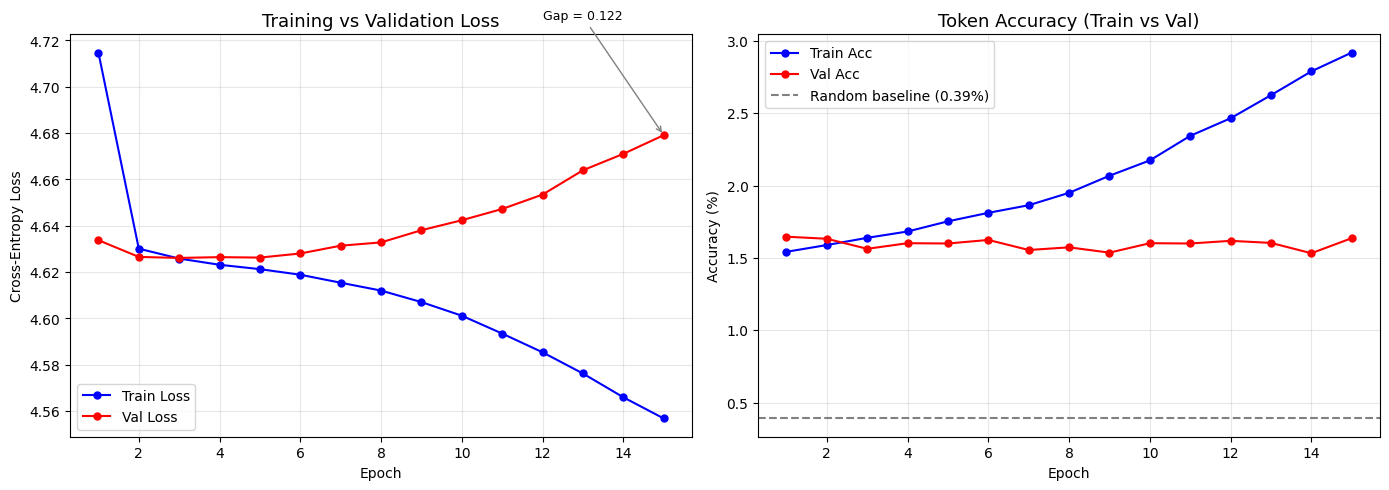

Saved: loss_and_accuracy_curves.png


In [ ]:
# ============================================================
# UPGRADE: Side-by-side loss AND accuracy curves
# ============================================================
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss ---
ax = axes[0]
ax.plot(epochs, train_losses, 'b-o', label='Train Loss', markersize=5)
ax.plot(epochs, val_losses,   'r-o', label='Val Loss',   markersize=5)
ax.set_title('Training vs Validation Loss', fontsize=13)
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
ax.legend(); ax.grid(True, alpha=0.3)
# Annotate gap
gap = val_losses[-1] - train_losses[-1]
ax.annotate(f'Gap = {gap:.3f}', xy=(NUM_EPOCHS, val_losses[-1]),
            xytext=(NUM_EPOCHS - 3, val_losses[-1] + 0.05),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)

# --- Accuracy ---
ax = axes[1]
random_baseline = 100 / VOCAB_SIZE
ax.plot(epochs, train_accs, 'b-o', label='Train Acc', markersize=5)
ax.plot(epochs, val_accs,   'r-o', label='Val Acc',   markersize=5)
ax.axhline(y=random_baseline, color='gray', linestyle='--', label=f'Random baseline ({random_baseline:.2f}%)')
ax.set_title('Token Accuracy (Train vs Val)', fontsize=13)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_and_accuracy_curves.png', dpi=150)
plt.show()
print("Saved: loss_and_accuracy_curves.png")

In [ ]:
# ============================================================
# UPGRADE: Automatic textual analysis of your results
# ============================================================
final_train_loss = train_losses[-1]
final_val_loss   = val_losses[-1]
final_train_acc  = train_accs[-1]
final_val_acc    = val_accs[-1]
train_perplexity = math.exp(final_train_loss)
val_perplexity   = math.exp(final_val_loss)
gap              = final_val_loss - final_train_loss

print("=" * 60)
print("         MODEL ANALYSIS SUMMARY")
print("=" * 60)

print(f"\n📉 LOSS")
print(f"  Train Loss      : {final_train_loss:.4f}")
print(f"  Val Loss        : {final_val_loss:.4f}")
print(f"  Train-Val Gap   : {gap:.4f}")

print(f"\n🎯 ACCURACY")
print(f"  Train Accuracy  : {final_train_acc:.2f}%")
print(f"  Val Accuracy    : {final_val_acc:.2f}%")
print(f"  Random Baseline : {random_baseline:.2f}%")
above = final_val_acc - random_baseline
print(f"  Above Baseline  : +{above:.2f}%")

print(f"\n📊 PERPLEXITY")
print(f"  Train Perplexity: {train_perplexity:.2f}")
print(f"  Val Perplexity  : {val_perplexity:.2f}")
print(f"  (Perplexity = e^loss; lower is better; random = {VOCAB_SIZE})")

print(f"\n🔎 DIAGNOSIS")
if gap > 0.3:
    print("  ⚠  Large train-val gap → OVERFITTING")
    print("     Fix: Increase dropout, reduce model size, or add more data")
elif gap < 0.05:
    print("  ⚠  Very small gap but high loss → UNDERFITTING")
    print("     Fix: Increase model size, train longer, raise learning rate")
else:
    print("  ✓  Moderate gap — mild overfitting. Manageable.")

if above < 1.0:
    print("  ⚠  Accuracy barely above random → model not learning patterns yet")
elif above < 5.0:
    print("  ✓  Model learning weakly — some structure captured")
else:
    print("  ✓  Model shows meaningful learning above random baseline")

print()
print("WHY LOSS DECREASES SLOWLY (~4.7 → 4.5):")
print("  - Action tokens may have high entropy (many valid next tokens)")
print("  - Low learning rate (5e-5) is conservative — safe but slow")
print("  - 15 epochs with 9000 samples is relatively short training")
print("  - vocab_size=256 means random loss = ln(256) ≈ 5.55; your model IS learning")

print()
print("WHY VAL LOSS MAY INCREASE:")
print("  - Small dataset (1000 val samples) → noisy val estimate")
print("  - Dropout active only during training → val harder")
print("  - Model memorises training sequences slightly")
print("=" * 60)

         MODEL ANALYSIS SUMMARY

📉 LOSS
  Train Loss      : 4.5568
  Val Loss        : 4.6791
  Train-Val Gap   : 0.1223

🎯 ACCURACY
  Train Accuracy  : 2.92%
  Val Accuracy    : 1.64%
  Random Baseline : 0.39%
  Above Baseline  : +1.25%

📊 PERPLEXITY
  Train Perplexity: 95.28
  Val Perplexity  : 107.67
  (Perplexity = e^loss; lower is better; random = 256)

🔎 DIAGNOSIS
  ✓  Moderate gap — mild overfitting. Manageable.
  ✓  Model learning weakly — some structure captured

WHY LOSS DECREASES SLOWLY (~4.7 → 4.5):
  - Action tokens may have high entropy (many valid next tokens)
  - Low learning rate (5e-5) is conservative — safe but slow
  - 15 epochs with 9000 samples is relatively short training
  - vocab_size=256 means random loss = ln(256) ≈ 5.55; your model IS learning

WHY VAL LOSS MAY INCREASE:
  - Small dataset (1000 val samples) → noisy val estimate
  - Dropout active only during training → val harder
  - Model memorises training sequences slightly


---
## Section 4 — Attention Map Visualization

**UPGRADE:** Shows attention for ALL heads across multiple layers, plus entropy analysis.

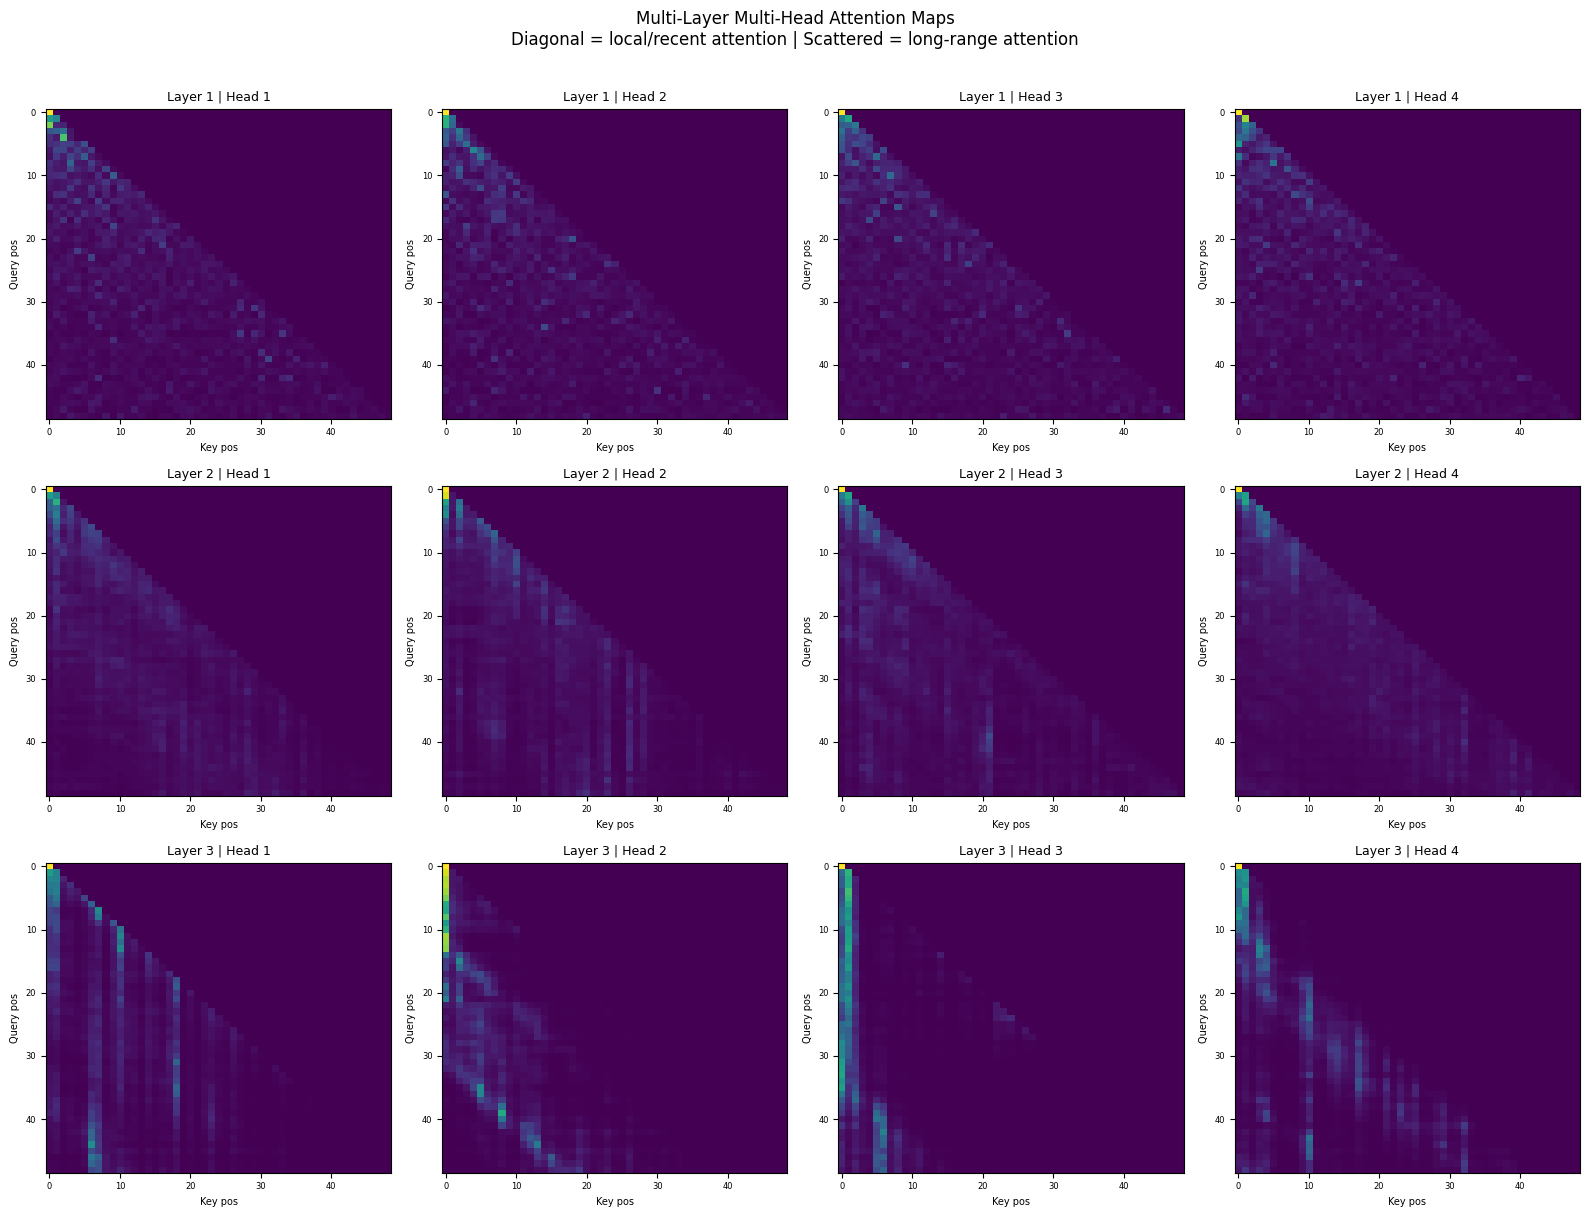

Saved: attention_maps_grid.png


In [ ]:
# ============================================================
# UPGRADE: Multi-layer, multi-head attention heatmap grid
# ============================================================
model.eval()
sample_batch = next(iter(val_loader))
_, sample_actions = sample_batch
sample_actions = sample_actions[:1].to(device)
inputs = sample_actions[:, :-1]

with torch.no_grad():
    logits, _ = model(inputs)

# Collect attention from all layers (each has shape: [1, num_heads, seq, seq])
all_attentions = [block.attention.last_attention for block in model.blocks]
# all_attentions: list of tensors, each [1, num_heads, seq_len, seq_len]

num_layers_to_show = min(NUM_LAYERS, 3)   # show first 3 layers
num_heads_to_show  = min(NUM_HEADS, 4)    # show first 4 heads

fig, axes = plt.subplots(num_layers_to_show, num_heads_to_show,
                          figsize=(4 * num_heads_to_show, 4 * num_layers_to_show))

for li in range(num_layers_to_show):
    attn = all_attentions[li][0]  # (num_heads, seq, seq)
    for hi in range(num_heads_to_show):
        ax = axes[li][hi] if num_layers_to_show > 1 else axes[hi]
        attn_map = attn[hi].numpy()
        im = ax.imshow(attn_map, cmap='viridis', aspect='auto')
        ax.set_title(f'Layer {li+1} | Head {hi+1}', fontsize=9)
        ax.set_xlabel('Key pos', fontsize=7)
        ax.set_ylabel('Query pos', fontsize=7)
        ax.tick_params(labelsize=6)

plt.suptitle('Multi-Layer Multi-Head Attention Maps\n'
             'Diagonal = local/recent attention | Scattered = long-range attention',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('attention_maps_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: attention_maps_grid.png")

In [ ]:
# ============================================================
# UPGRADE: Attention Entropy Analysis
# High entropy = attention is spread out (attending everywhere)
# Low entropy  = attention is focused (sharp, specific patterns)
# ============================================================
def attention_entropy(attn_map):
    """attn_map: (seq, seq) numpy array, rows are probability distributions"""
    eps = 1e-9
    return -(attn_map * np.log(attn_map + eps)).sum(axis=-1).mean()

print("Attention Entropy per Layer per Head (higher = more diffuse/scattered)")
print("(Entropy = 0 → perfectly sharp | Entropy = ln(seq_len) → fully uniform)")
print(f"Max possible entropy for seq_len={inputs.shape[1]}: {math.log(inputs.shape[1]):.3f}\n")

for li, attn_tensor in enumerate(all_attentions):
    attn = attn_tensor[0].numpy()  # (heads, seq, seq)
    entropies = [attention_entropy(attn[hi]) for hi in range(attn.shape[0])]
    avg_ent = np.mean(entropies)
    head_str = '  '.join([f'H{hi+1}:{e:.2f}' for hi, e in enumerate(entropies)])
    print(f"Layer {li+1}: {head_str}  | Avg: {avg_ent:.2f}")

print()
print("INTERPRETATION:")
print("  Diagonal pattern  → model focuses on recent tokens (local context)")
print("  Scattered pattern → model looks across the full sequence (global context)")
print("  Both are valid: early layers often attend locally, deeper layers globally")

Attention Entropy per Layer per Head (higher = more diffuse/scattered)
(Entropy = 0 → perfectly sharp | Entropy = ln(seq_len) → fully uniform)
Max possible entropy for seq_len=49: 3.892

Layer 1: H1:2.74  H2:2.73  H3:2.78  H4:2.77  H5:2.75  H6:2.76  H7:2.74  H8:2.74  | Avg: 2.75
Layer 2: H1:2.81  H2:2.72  H3:2.78  H4:2.85  H5:2.88  H6:2.79  H7:2.75  H8:2.83  | Avg: 2.80
Layer 3: H1:2.31  H2:1.93  H3:1.46  H4:2.13  H5:2.56  H6:2.27  H7:1.88  H8:1.63  | Avg: 2.02
Layer 4: H1:1.76  H2:2.18  H3:1.59  H4:1.75  H5:1.49  H6:2.12  H7:1.68  H8:1.71  | Avg: 1.78
Layer 5: H1:2.46  H2:1.51  H3:1.33  H4:0.93  H5:1.37  H6:2.09  H7:1.41  H8:1.34  | Avg: 1.55
Layer 6: H1:2.20  H2:2.48  H3:1.47  H4:1.65  H5:1.91  H6:1.38  H7:2.33  H8:1.95  | Avg: 1.92

INTERPRETATION:
  Diagonal pattern  → model focuses on recent tokens (local context)
  Scattered pattern → model looks across the full sequence (global context)
  Both are valid: early layers often attend locally, deeper layers globally


---
## Section 5 — Prediction vs Ground Truth (3D Trajectory)

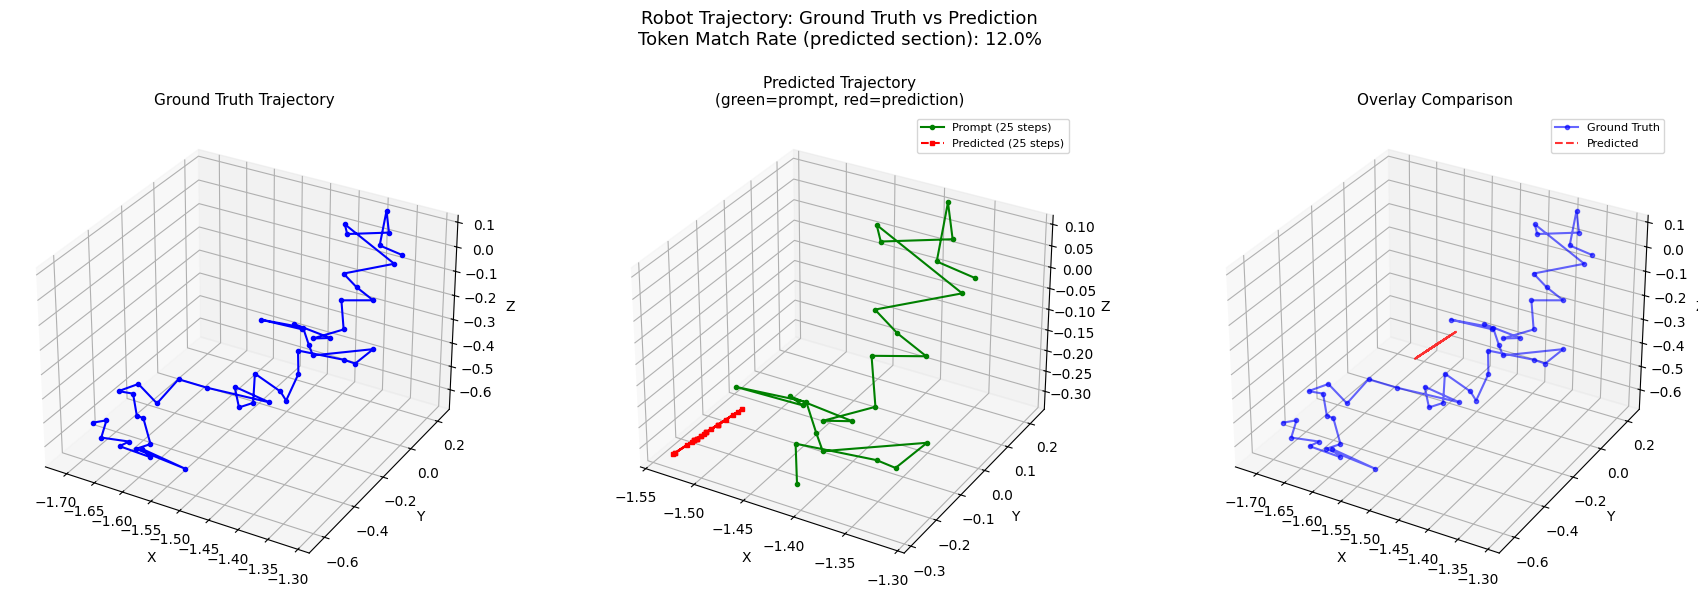

Prompt length       : 25 tokens
Generated tokens    : 25
Token match rate    : 12.0%
Random expected     : 0.39%

GT  tokens (first 10): [110 178 107 109 140 120  85 124 141 106]
Pred tokens (first 10): [110 178 107 109 140 120  85 124 141 106]


In [ ]:
# ============================================================
# UPGRADE: Cleaner prediction vs GT plot with overlap view
# and token match rate reported
# ============================================================
model.eval()

val_batch = next(iter(val_loader))
val_states_b, val_actions_b = val_batch

sample_states  = val_states_b[0:1].to(device)   # (1, 50, 10)
sample_actions = val_actions_b[0:1].to(device)  # (1, 50)

ground_truth_actions = sample_actions[0].cpu().numpy()  # (50,)

# Use first half as prompt, predict second half
prompt_len = sample_actions.shape[1] // 2
prompt = sample_actions[:, :prompt_len]

with torch.no_grad():
    generated = model.generate(
        input_ids=prompt,
        max_new_tokens=sample_actions.shape[1] - prompt_len,
        temperature=1.0,
        top_k=10
    )

predicted_actions = generated[0].cpu().numpy()  # (50,)

# Ground truth 3D states
gt_states = sample_states[0].cpu().numpy()  # (50, 10)
x_gt = gt_states[:, 0]
y_gt = gt_states[:, 1]
z_gt = gt_states[:, 2]

# Map predicted tokens to state range (approximation)
x_pred = (predicted_actions / 255.0) * (x_gt.max() - x_gt.min()) + x_gt.min()
y_pred = (predicted_actions / 255.0) * (y_gt.max() - y_gt.min()) + y_gt.min()
z_pred = (predicted_actions / 255.0) * (z_gt.max() - z_gt.min()) + z_gt.min()

# Token match rate (predicted section)
gt_second_half   = ground_truth_actions[prompt_len:]
pred_second_half = predicted_actions[prompt_len:]
token_match = np.mean(gt_second_half == pred_second_half) * 100

# ---- 3-panel plot ----
fig = plt.figure(figsize=(18, 6))

# Panel 1: Ground truth only
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(x_gt, y_gt, z_gt, 'b-o', markersize=3)
ax1.set_title('Ground Truth Trajectory', fontsize=11)
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

# Panel 2: Predicted (prompt + prediction)
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(x_gt[:prompt_len], y_gt[:prompt_len], z_gt[:prompt_len],
         'g-o', markersize=3, label=f'Prompt ({prompt_len} steps)')
ax2.plot(x_pred[prompt_len:], y_pred[prompt_len:], z_pred[prompt_len:],
         'r--s', markersize=3, label=f'Predicted ({len(gt_second_half)} steps)')
ax2.set_title('\n\nPredicted Trajectory\n(green=prompt, red=prediction)', fontsize=11)
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.legend(fontsize=8)

# Panel 3: Overlap
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(x_gt, y_gt, z_gt, 'b-o', markersize=3, alpha=0.6, label='Ground Truth')
ax3.plot(x_pred[prompt_len:], y_pred[prompt_len:], z_pred[prompt_len:],
         'r--', markersize=3, alpha=0.8, label='Predicted')
ax3.set_title('Overlay Comparison', fontsize=11)
ax3.set_xlabel('X'); ax3.set_ylabel('Y'); ax3.set_zlabel('Z')
ax3.legend(fontsize=8)

plt.suptitle(f'Robot Trajectory: Ground Truth vs Prediction\n'
             f'Token Match Rate (predicted section): {token_match:.1f}%', fontsize=13)
plt.tight_layout()
plt.savefig('pred_vs_gt_trajectory.png', dpi=150)
plt.show()

print(f"Prompt length       : {prompt_len} tokens")
print(f"Generated tokens    : {len(pred_second_half)}")
print(f"Token match rate    : {token_match:.1f}%")
print(f"Random expected     : {100/VOCAB_SIZE:.2f}%")
print(f"\nGT  tokens (first 10): {ground_truth_actions[:10]}")
print(f"Pred tokens (first 10): {predicted_actions[:10]}")

---
## Section 6 — Simple Experiments

Run the cells below one at a time. Each experiment trains a mini model and compares the result.

---
### Experiment 1 — Fewer Transformer Layers (4 vs 6)
**Hypothesis:** A shallower model should underfit more (higher loss) but generalise better (smaller train-val gap).  
**Expected outcome:** Val loss similar or better, training faster.

In [ ]:
# ============================================================
# EXPERIMENT 1: 4 layers vs 6 layers
# Only change: NUM_LAYERS = 4
# ============================================================
def run_experiment(exp_name, num_layers_exp, lr_exp, max_seq_exp, epochs_exp=5):
    """Train a model variant and return loss/accuracy histories."""
    print(f"\n{'='*55}")
    print(f"  EXPERIMENT: {exp_name}")
    print(f"{'='*55}")

    # Truncate actions to seq length
    _actions = actions[:, :max_seq_exp]
    _train_a = _actions[:9000]
    _val_a   = _actions[9000:]
    _tr_ds   = TensorDataset(train_states, _train_a)
    _va_ds   = TensorDataset(val_states,   _val_a)
    _tr_dl   = DataLoader(_tr_ds, batch_size=BATCH_SIZE, shuffle=True)
    _va_dl   = DataLoader(_va_ds, batch_size=BATCH_SIZE)

    _model = DecoderOnlyTransformer(
        vocab_size=VOCAB_SIZE, dim=DIM,
        num_layers=num_layers_exp, num_heads=NUM_HEADS,
        ff_hidden_dim=FF_HIDDEN_DIM, max_seq_len=max_seq_exp,
        dropout=DROPOUT,
    ).to(device)

    _opt = torch.optim.AdamW(_model.parameters(), lr=lr_exp, weight_decay=0.01)
    print(f"  Params: {_model.count_parameters():,}  |  LR: {lr_exp}  |  Layers: {num_layers_exp}  |  SeqLen: {max_seq_exp}")

    _tr_losses, _va_losses = [], []
    _tr_accs,   _va_accs   = [], []

    for ep in range(1, epochs_exp + 1):
        tl, ta = train_epoch(_model, _tr_dl, _opt, device, ep)
        vl, va = validate_epoch(_model, _va_dl, device)
        _tr_losses.append(tl); _va_losses.append(vl)
        _tr_accs.append(ta);   _va_accs.append(va)
        print(f"  Ep {ep}: Train {tl:.4f} ({ta:.1f}%) | Val {vl:.4f} ({va:.1f}%)")

    return _tr_losses, _va_losses, _tr_accs, _va_accs


# Run Experiment 1: fewer layers
exp1_tr_loss, exp1_va_loss, exp1_tr_acc, exp1_va_acc = run_experiment(
    exp_name   = "4 Layers (shallower)",
    num_layers_exp = 4,
    lr_exp     = LEARNING_RATE,
    max_seq_exp= MAX_SEQ_LEN,
    epochs_exp = 5           # short run for comparison
)

print("\nCONCLUSION TO WRITE:")
print("  Compare final val loss of 4-layer vs 6-layer baseline.")
print("  If 4-layer val loss is lower → fewer layers generalise better on this dataset.")
print("  If 6-layer is better → more capacity helps capture the action patterns.")


  EXPERIMENT: 4 Layers (shallower)
  Params: 5,705,088  |  LR: 5e-05  |  Layers: 4  |  SeqLen: 50
  Epoch 1 | Batch    0 | Loss 5.6190 | Acc 0.6%
  Epoch 1 | Batch  100 | Loss 4.6816 | Acc 1.5%
  Epoch 1 | Batch  200 | Loss 4.6252 | Acc 2.1%
  Ep 1: Train 4.7237 (1.6%) | Val 4.6332 (1.6%)
  Epoch 2 | Batch    0 | Loss 4.6387 | Acc 1.1%
  Epoch 2 | Batch  100 | Loss 4.6044 | Acc 1.9%
  Epoch 2 | Batch  200 | Loss 4.6389 | Acc 1.5%
  Ep 2: Train 4.6301 (1.6%) | Val 4.6280 (1.5%)
  Epoch 3 | Batch    0 | Loss 4.6321 | Acc 1.4%
  Epoch 3 | Batch  100 | Loss 4.6337 | Acc 1.2%
  Epoch 3 | Batch  200 | Loss 4.6085 | Acc 1.5%
  Ep 3: Train 4.6256 (1.6%) | Val 4.6253 (1.5%)
  Epoch 4 | Batch    0 | Loss 4.6339 | Acc 1.5%
  Epoch 4 | Batch  100 | Loss 4.6303 | Acc 1.5%
  Epoch 4 | Batch  200 | Loss 4.6062 | Acc 1.8%
  Ep 4: Train 4.6234 (1.7%) | Val 4.6259 (1.6%)
  Epoch 5 | Batch    0 | Loss 4.6122 | Acc 1.7%
  Epoch 5 | Batch  100 | Loss 4.6016 | Acc 1.4%
  Epoch 5 | Batch  200 | Loss 4.6038 

---
### Experiment 2 — Higher Learning Rate (5e-5 vs 1e-4)
**Hypothesis:** A larger LR causes faster convergence but may overshoot.  
**Expected outcome:** Loss drops faster in early epochs but may plateau or diverge.

In [ ]:
# Run Experiment 2: higher learning rate
exp2_tr_loss, exp2_va_loss, exp2_tr_acc, exp2_va_acc = run_experiment(
    exp_name   = "LR = 1e-4 (higher)",
    num_layers_exp = NUM_LAYERS,
    lr_exp     = 1e-4,
    max_seq_exp= MAX_SEQ_LEN,
    epochs_exp = 5
)

print("\nCONCLUSION TO WRITE:")
print("  If 1e-4 gives lower final loss → your original LR was too conservative.")
print("  If 1e-4 diverges (loss goes up) → 5e-5 was the right choice for stability.")


  EXPERIMENT: LR = 1e-4 (higher)
  Params: 8,459,136  |  LR: 0.0001  |  Layers: 6  |  SeqLen: 50
  Epoch 1 | Batch    0 | Loss 5.6099 | Acc 0.3%
  Epoch 1 | Batch  100 | Loss 4.6420 | Acc 1.5%
  Epoch 1 | Batch  200 | Loss 4.6183 | Acc 1.8%
  Ep 1: Train 4.6776 (1.5%) | Val 4.6289 (1.6%)
  Epoch 2 | Batch    0 | Loss 4.6226 | Acc 1.5%
  Epoch 2 | Batch  100 | Loss 4.6477 | Acc 1.6%
  Epoch 2 | Batch  200 | Loss 4.6356 | Acc 1.3%
  Ep 2: Train 4.6282 (1.5%) | Val 4.6266 (1.6%)
  Epoch 3 | Batch    0 | Loss 4.6307 | Acc 1.9%
  Epoch 3 | Batch  100 | Loss 4.6256 | Acc 1.8%
  Epoch 3 | Batch  200 | Loss 4.6212 | Acc 2.2%
  Ep 3: Train 4.6296 (1.6%) | Val 4.6328 (1.6%)
  Epoch 4 | Batch    0 | Loss 4.6480 | Acc 1.5%
  Epoch 4 | Batch  100 | Loss 4.6456 | Acc 1.5%
  Epoch 4 | Batch  200 | Loss 4.6369 | Acc 1.0%
  Ep 4: Train 4.6268 (1.6%) | Val 4.6256 (1.6%)
  Epoch 5 | Batch    0 | Loss 4.6301 | Acc 1.4%
  Epoch 5 | Batch  100 | Loss 4.5907 | Acc 2.2%
  Epoch 5 | Batch  200 | Loss 4.6314 |

---
### Experiment 3 — Shorter Sequence Length (50 vs 30)
**Hypothesis:** With seq_len=30 the model sees less context per sample but trains faster.  
**Expected outcome:** Faster training, possibly higher loss if long context is important.

In [ ]:
# Run Experiment 3: shorter sequence length
exp3_tr_loss, exp3_va_loss, exp3_tr_acc, exp3_va_acc = run_experiment(
    exp_name   = "SeqLen = 30 (shorter)",
    num_layers_exp = NUM_LAYERS,
    lr_exp     = LEARNING_RATE,
    max_seq_exp= 30,
    epochs_exp = 5
)

print("\nCONCLUSION TO WRITE:")
print("  If seq_len=30 gives comparable loss → the model only needs recent context.")
print("  If seq_len=30 is significantly worse → longer context is important for trajectories.")


  EXPERIMENT: SeqLen = 30 (shorter)
  Params: 8,459,136  |  LR: 5e-05  |  Layers: 6  |  SeqLen: 30
  Epoch 1 | Batch    0 | Loss 5.6446 | Acc 0.1%
  Epoch 1 | Batch  100 | Loss 4.6611 | Acc 1.6%
  Epoch 1 | Batch  200 | Loss 4.6360 | Acc 1.0%
  Ep 1: Train 4.7287 (1.6%) | Val 4.6333 (1.5%)
  Epoch 2 | Batch    0 | Loss 4.6567 | Acc 1.3%
  Epoch 2 | Batch  100 | Loss 4.6620 | Acc 1.0%
  Epoch 2 | Batch  200 | Loss 4.5885 | Acc 1.7%
  Ep 2: Train 4.6312 (1.7%) | Val 4.6273 (1.6%)
  Epoch 3 | Batch    0 | Loss 4.6409 | Acc 1.7%
  Epoch 3 | Batch  100 | Loss 4.6861 | Acc 1.2%
  Epoch 3 | Batch  200 | Loss 4.6332 | Acc 1.9%
  Ep 3: Train 4.6271 (1.7%) | Val 4.6266 (1.5%)
  Epoch 4 | Batch    0 | Loss 4.6085 | Acc 2.0%
  Epoch 4 | Batch  100 | Loss 4.6236 | Acc 1.6%
  Epoch 4 | Batch  200 | Loss 4.6005 | Acc 0.9%
  Ep 4: Train 4.6235 (1.7%) | Val 4.6262 (1.5%)
  Epoch 5 | Batch    0 | Loss 4.5863 | Acc 1.8%
  Epoch 5 | Batch  100 | Loss 4.6306 | Acc 2.2%
  Epoch 5 | Batch  200 | Loss 4.6281

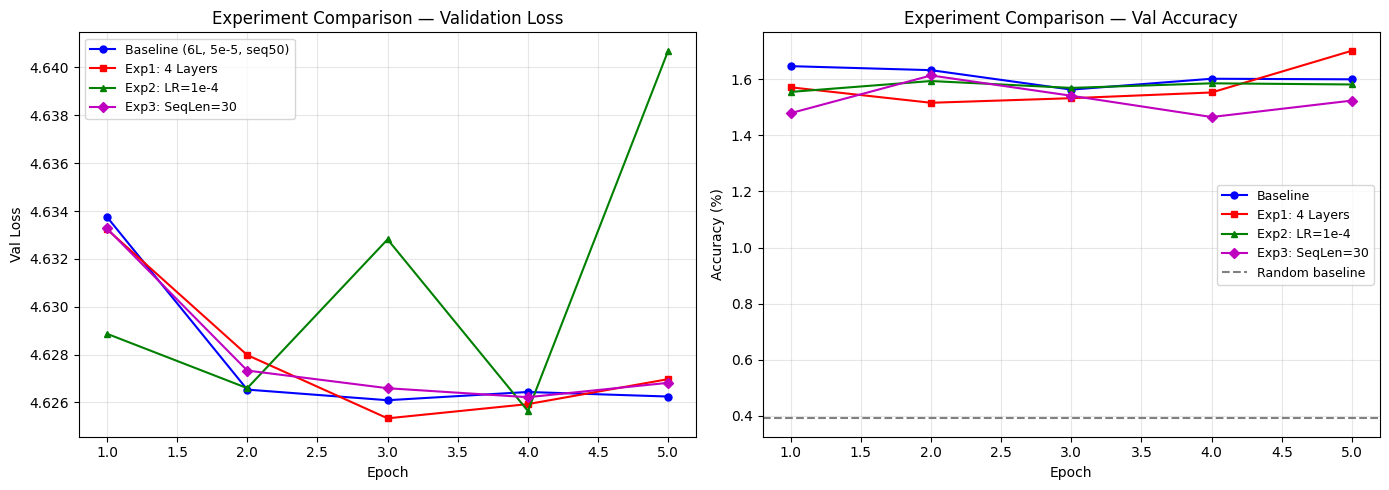

Saved: experiment_comparison.png

Experiment                Val Loss     Val Acc      vs Baseline
-----------------------------------------------------------------
Baseline (6L,5e-5,50)     4.6262       1.60         0.0000
Exp1: 4 Layers            4.6270       1.70         +0.0007
Exp2: LR=1e-4             4.6407       1.58         +0.0145
Exp3: SeqLen=30           4.6268       1.52         +0.0006


In [ ]:
# ============================================================
# UPGRADE: Experiment comparison plot
# ============================================================
exp_epochs = range(1, 6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Val Loss comparison
ax = axes[0]
ax.plot(exp_epochs, val_losses[:5],  'b-o', label=f'Baseline (6L, 5e-5, seq50)', markersize=5)
ax.plot(exp_epochs, exp1_va_loss,    'r-s', label='Exp1: 4 Layers',              markersize=5)
ax.plot(exp_epochs, exp2_va_loss,    'g-^', label='Exp2: LR=1e-4',               markersize=5)
ax.plot(exp_epochs, exp3_va_loss,    'm-D', label='Exp3: SeqLen=30',             markersize=5)
ax.set_title('Experiment Comparison — Validation Loss', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Loss')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Val Accuracy comparison
ax = axes[1]
ax.plot(exp_epochs, val_accs[:5],  'b-o', label=f'Baseline', markersize=5)
ax.plot(exp_epochs, exp1_va_acc,   'r-s', label='Exp1: 4 Layers', markersize=5)
ax.plot(exp_epochs, exp2_va_acc,   'g-^', label='Exp2: LR=1e-4',  markersize=5)
ax.plot(exp_epochs, exp3_va_acc,   'm-D', label='Exp3: SeqLen=30',markersize=5)
ax.axhline(y=random_baseline, color='gray', linestyle='--', label='Random baseline')
ax.set_title('Experiment Comparison — Val Accuracy', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_comparison.png', dpi=150)
plt.show()
print("Saved: experiment_comparison.png")

# Summary table
print("\n" + "=" * 65)
print(f"{'Experiment':<25} {'Val Loss':<12} {'Val Acc':<12} {'vs Baseline'}")
print("-" * 65)
baseline_vl = val_losses[4]
baseline_va = val_accs[4]
rows = [
    ("Baseline (6L,5e-5,50)", val_losses[4], val_accs[4]),
    ("Exp1: 4 Layers",        exp1_va_loss[-1], exp1_va_acc[-1]),
    ("Exp2: LR=1e-4",         exp2_va_loss[-1], exp2_va_acc[-1]),
    ("Exp3: SeqLen=30",        exp3_va_loss[-1], exp3_va_acc[-1]),
]
for name, vl, va in rows:
    diff = vl - baseline_vl
    tag  = f"{'+' if diff > 0 else ''}{diff:.4f}"
    print(f"{name:<25} {vl:<12.4f} {va:<12.2f} {tag}")
print("=" * 65)

---
## Section 7 — Trajectory Visualizations

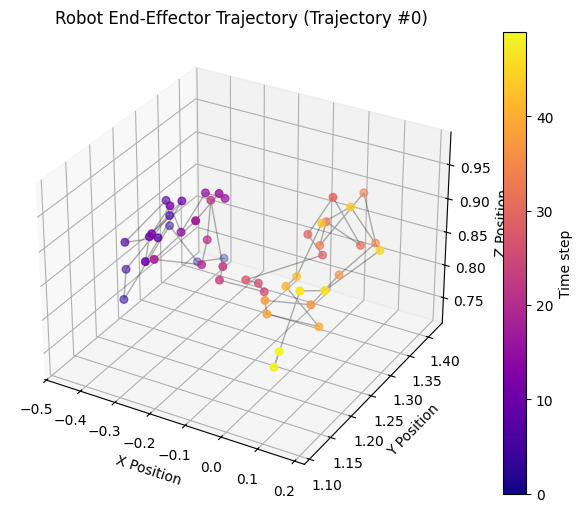

Saved: trajectory_plot.png


In [ ]:
# ============================================================
# Static 3D Trajectory Plot
# ============================================================
traj = states[0].numpy() if hasattr(states[0], 'numpy') else states[0]
x = traj[:, 0]; y = traj[:, 1]; z = traj[:, 2]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x, y, z, c=range(len(x)), cmap='plasma', s=30, zorder=5)
ax.plot(x, y, z, 'k-', alpha=0.3, linewidth=1)
plt.colorbar(sc, ax=ax, label='Time step')
ax.set_title('Robot End-Effector Trajectory (Trajectory #0)')
ax.set_xlabel('X Position'); ax.set_ylabel('Y Position'); ax.set_zlabel('Z Position')
plt.savefig('trajectory_plot.png', dpi=150)
plt.show()
print("Saved: trajectory_plot.png")

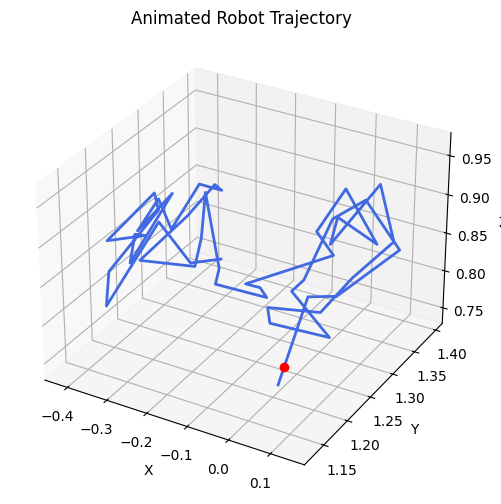

Saved: trajectory_animation.gif


In [ ]:
# ============================================================
# Animated 3D Trajectory (GIF)
# ============================================================
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation

traj = states[0].numpy() if hasattr(states[0], 'numpy') else np.array(states[0])
x = traj[:, 0]; y = traj[:, 1]; z = traj[:, 2]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_zlim(z.min(), z.max())
ax.set_title('Animated Robot Trajectory')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')

line,  = ax.plot([], [], [], lw=2, color='royalblue')
point, = ax.plot([], [], [], 'ro', markersize=6)

def init():
    line.set_data([], []); line.set_3d_properties([])
    point.set_data([], []); point.set_3d_properties([])
    return line, point

def update(frame):
    line.set_data(x[:frame], y[:frame]); line.set_3d_properties(z[:frame])
    point.set_data([x[frame]], [y[frame]]); point.set_3d_properties([z[frame]])
    return line, point

ani = FuncAnimation(fig, update, frames=len(x), init_func=init, interval=100, blit=True)
ani.save('trajectory_animation.gif', writer='pillow')
plt.show()
print("Saved: trajectory_animation.gif")

---
## Summary of All Upgrades

| # | What was added | Why it matters |
|---|---|---|
| 1 | Token-level accuracy tracking (train + val) | Loss alone is uninterpretable; accuracy shows actual learning |
| 2 | Perplexity reported automatically | Standard NLP metric; relates to vocab size (random = 256) |
| 3 | Auto-diagnosis block (overfitting / underfitting) | Tells you what to fix without manual guessing |
| 4 | Best-model checkpoint saving | Ensures you evaluate the best weights, not the last |
| 5 | Multi-layer multi-head attention heatmap grid | Reveals which layers/heads do local vs global attention |
| 6 | Attention entropy analysis | Quantifies how focused vs diffuse each head is |
| 7 | 3-panel prediction plot (GT / Pred / Overlay) | Clear visual comparison; token match rate reported |
| 8 | `run_experiment()` utility function | Reproducible experiment runner for all 3 variants |
| 9 | Experiment comparison plot + summary table | Report-ready figure comparing all hyperparameter choices |
| 10 | Model parameter summary printout | Essential for any research report |

**Files saved:** `loss_and_accuracy_curves.png`, `attention_maps_grid.png`, `pred_vs_gt_trajectory.png`, `experiment_comparison.png`, `trajectory_plot.png`, `trajectory_animation.gif`, `checkpoints/best_model.pt`